<div style="
background: linear-gradient(90deg, #82065f, #f317ca);
padding: 25px;
border-radius: 10px;
text-align: center;
color: white;
font-family: Arial;
">

<h1 style="margin-bottom:5px;">Employee Turnover Prediction</h1>

<h3 style="margin-top:0;">
Identifying Employees at Risk of Leaving the Company
</h3>

<p>
Hackathon Project • HR Analytics • Explainable AI
</p>

</div>

# Goal

The goal of this project is to predict voluntary employee turnover.
The analysis will help HR identify employees at risk of leaving the company
and understand the factors contributing to their departure.

# Analysis of the dataset

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset and display basic information

In [194]:
df = pd.read_csv("../data/HRDataset_v14.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [195]:
# Display the shape of the dataset
print("Shape du dataset :", df.shape)

Shape du dataset : (311, 36)


In [196]:
# Display columns and types 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    str    
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    str    
 13  State                       311 non-null    st

In [197]:
# Display all the columns
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='str')

In [198]:
# statistical infomation
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [199]:
# Display the missing values 
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

DateofTermination             207
ManagerID                       8
Employee_Name                   0
EmpID                           0
MaritalStatusID                 0
MarriedID                       0
GenderID                        0
EmpStatusID                     0
FromDiversityJobFairID          0
Salary                          0
DeptID                          0
PerfScoreID                     0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
Termd                           0
PositionID                      0
HispanicLatino                  0
CitizenDesc                     0
DateofHire                      0
RaceDesc                        0
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
RecruitmentSource               0
PerformanceSco

Initial distribution of Termd before filtering:
Termd
0    207
1    104
Name: count, dtype: int64

Initial distribution in percentage:
Termd
0    66.559486
1    33.440514
Name: proportion, dtype: float64


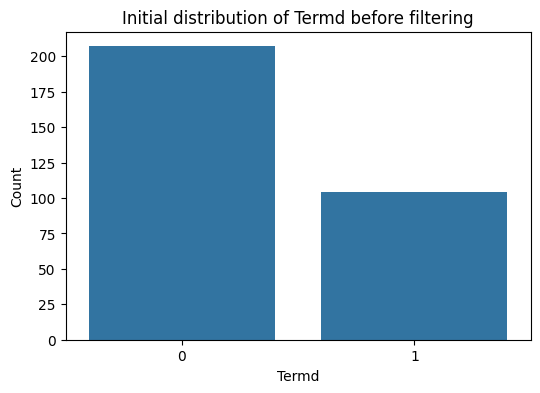

In [200]:
# Initial distribution of Termd before filtering

target = "Termd"

print("Initial distribution of Termd before filtering:")
print(df[target].value_counts())

print("\nInitial distribution in percentage:")
print(df[target].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title(f"Initial distribution of {target} before filtering")
plt.xlabel(target)
plt.ylabel("Count")
plt.show()

In [201]:
# Display the reasons of the departure 
df["TermReason"].value_counts()

TermReason
N/A-StillEmployed                   207
Another position                     20
unhappy                              14
more money                           11
career change                         9
hours                                 8
attendance                            7
return to school                      5
relocation out of area                5
performance                           4
retiring                              4
military                              4
no-call, no-show                      4
maternity leave - did not return      3
medical issues                        3
Learned that he is a gangster         1
Fatal attraction                      1
gross misconduct                      1
Name: count, dtype: int64

The dataset contains employee demographic information,
performance indicators and employment history.

### Filtering the dataset

To focus on voluntary employee turnover, we remove cases where employees
were terminated by the.

In [202]:
#filtrage 
voluntary_reasons = [
    "Another position",
    "unhappy",
    "more money",
    "career change",
    "hours",
    "return to school",
    "relocation out of area",
    "maternity leave - did not return",
    "retiring",
    "military",
    "medical issues"
]

df_filtered = df[
    (df["TermReason"] == "N/A-StillEmployed") |
    (df["TermReason"].isin(voluntary_reasons))
]

In [203]:
print("Initial number :", len(df))
print("After filtering :", len(df_filtered))

Initial number : 311
After filtering : 293


In [204]:
#verifications of the reasons we decided to keep
df_filtered["TermReason"].value_counts()

TermReason
N/A-StillEmployed                   207
Another position                     20
unhappy                              14
more money                           11
career change                         9
hours                                 8
return to school                      5
relocation out of area                5
retiring                              4
military                              4
maternity leave - did not return      3
medical issues                        3
Name: count, dtype: int64

Distribution of the target variable after filtering:
Termd
0    207
1     86
Name: count, dtype: int64

Distribution in percentage:
Termd
0    70.648464
1    29.351536
Name: proportion, dtype: float64


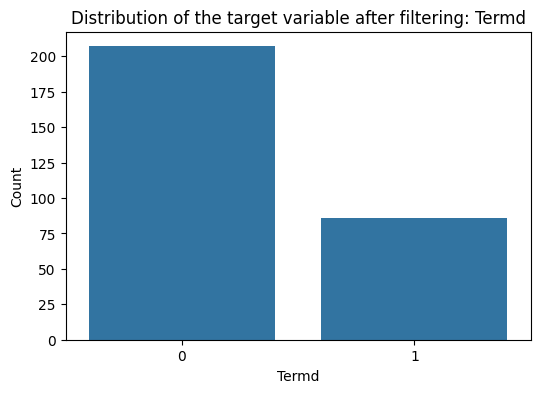

In [205]:
# Distribution of the target variable AFTER filtering

target = "Termd"

print("Distribution of the target variable after filtering:")
print(df_filtered[target].value_counts())

print("\nDistribution in percentage:")
print(df_filtered[target].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df_filtered)
plt.title(f"Distribution of the target variable after filtering: {target}")
plt.xlabel(target)
plt.ylabel("Count")
plt.show()

### Encodage des variables (df_filtered)
Les blocs suivants encodent TermReason puis les variables demographiques pour preparer une matrice de correlation.


In [206]:
# Encodage de TermReason (1..12)
term_mapping = {reason: idx + 1 for idx, reason in enumerate(sorted(df_filtered['TermReason'].unique()))}
df_filtered['TermReason_enc'] = df_filtered['TermReason'].map(term_mapping)
print('TermReason mapping:', term_mapping)
df_filtered[['TermReason', 'TermReason_enc']].drop_duplicates().sort_values('TermReason')


TermReason mapping: {'Another position': 1, 'N/A-StillEmployed': 2, 'career change': 3, 'hours': 4, 'maternity leave - did not return': 5, 'medical issues': 6, 'military': 7, 'more money': 8, 'relocation out of area': 9, 'retiring': 10, 'return to school': 11, 'unhappy': 12}


,TermReason,TermReason_enc
10,Another position,1
0,N/A-StillEmployed,2
1,career change,3
2,hours,4
147,maternity leave - did not return,5
216,medical issues,6
80,military,7
68,more money,8
46,relocation out of area,9
27,retiring,10


In [207]:
# Encodage binaire HispanicLatino (Yes=1, No=0)
df_filtered['HispanicLatino_enc'] = df_filtered['HispanicLatino'].str.strip().str.lower().map({'yes': 1, 'no': 0})
print(df_filtered['HispanicLatino_enc'].value_counts(dropna=False))
df_filtered[['HispanicLatino', 'HispanicLatino_enc']].drop_duplicates()


HispanicLatino_enc
0    266
1     27
Name: count, dtype: int64


,HispanicLatino,HispanicLatino_enc
0,No,0
10,Yes,1
97,no,0
187,yes,1


In [208]:
# Encodage de State (ordinal)
state_mapping = {state: idx for idx, state in enumerate(sorted(df_filtered['State'].dropna().unique()))}
df_filtered['State_enc'] = df_filtered['State'].map(state_mapping)
print('State mapping:', state_mapping)
df_filtered[['State', 'State_enc']].drop_duplicates().sort_values('State')


State mapping: {'AL': 0, 'AZ': 1, 'CA': 2, 'CO': 3, 'CT': 4, 'FL': 5, 'GA': 6, 'ID': 7, 'IN': 8, 'KY': 9, 'MA': 10, 'ME': 11, 'MT': 12, 'NC': 13, 'ND': 14, 'NH': 15, 'NV': 16, 'NY': 17, 'OR': 18, 'PA': 19, 'RI': 20, 'TN': 21, 'TX': 22, 'UT': 23, 'VA': 24, 'VT': 25, 'WA': 26}


,State,State_enc
67,AL,0
288,AZ,1
77,CA,2
149,CO,3
59,CT,4
207,FL,5
202,GA,6
230,ID,7
107,IN,8
223,KY,9


In [209]:
# Encodage de CitizenDesc
cit_mapping = {c: idx for idx, c in enumerate(sorted(df_filtered['CitizenDesc'].dropna().unique()))}
df_filtered['CitizenDesc_enc'] = df_filtered['CitizenDesc'].map(cit_mapping)
print('CitizenDesc mapping:', cit_mapping)
df_filtered[['CitizenDesc', 'CitizenDesc_enc']].drop_duplicates().sort_values('CitizenDesc')


CitizenDesc mapping: {'Eligible NonCitizen': 0, 'Non-Citizen': 1, 'US Citizen': 2}


,CitizenDesc,CitizenDesc_enc
17,Eligible NonCitizen,0
47,Non-Citizen,1
0,US Citizen,2


In [210]:
# Encodage de RaceDesc
race_mapping = {race: idx for idx, race in enumerate(sorted(df_filtered['RaceDesc'].dropna().unique()))}
df_filtered['RaceDesc_enc'] = df_filtered['RaceDesc'].map(race_mapping)
print('RaceDesc mapping:', race_mapping)
df_filtered[['RaceDesc', 'RaceDesc_enc']].drop_duplicates().sort_values('RaceDesc')


RaceDesc mapping: {'American Indian or Alaska Native': 0, 'Asian': 1, 'Black or African American': 2, 'Hispanic': 3, 'Two or more races': 4, 'White': 5}


,RaceDesc,RaceDesc_enc
116,American Indian or Alaska Native,0
19,Asian,1
8,Black or African American,2
187,Hispanic,3
13,Two or more races,4
0,White,5


In [211]:
# Features d'age et d'anciennete (Age & Tenure depuis aujourd'hui)
today = pd.Timestamp.today().normalize()
dob = pd.to_datetime(df_filtered['DOB'], errors='coerce')
age_years = (today - dob).dt.days / 365.25
df_filtered['Age'] = np.ceil(age_years.clip(lower=0)).astype('Int64')
hire = pd.to_datetime(df_filtered['DateofHire'], errors='coerce')
tenure_years = (today - hire).dt.days / 365.25
df_filtered['TenureYears'] = np.ceil(tenure_years.clip(lower=0)).astype('Int64')
df_filtered[['Age', 'TenureYears']].head()


/tmp/ipykernel_7173/4112265569.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dob = pd.to_datetime(df_filtered['DOB'], errors='coerce')


,Age,TenureYears
0,43,15
1,0,11
2,38,15
3,38,19
4,37,15


### Correlation matrix

Correlation matrix with the numerical variable

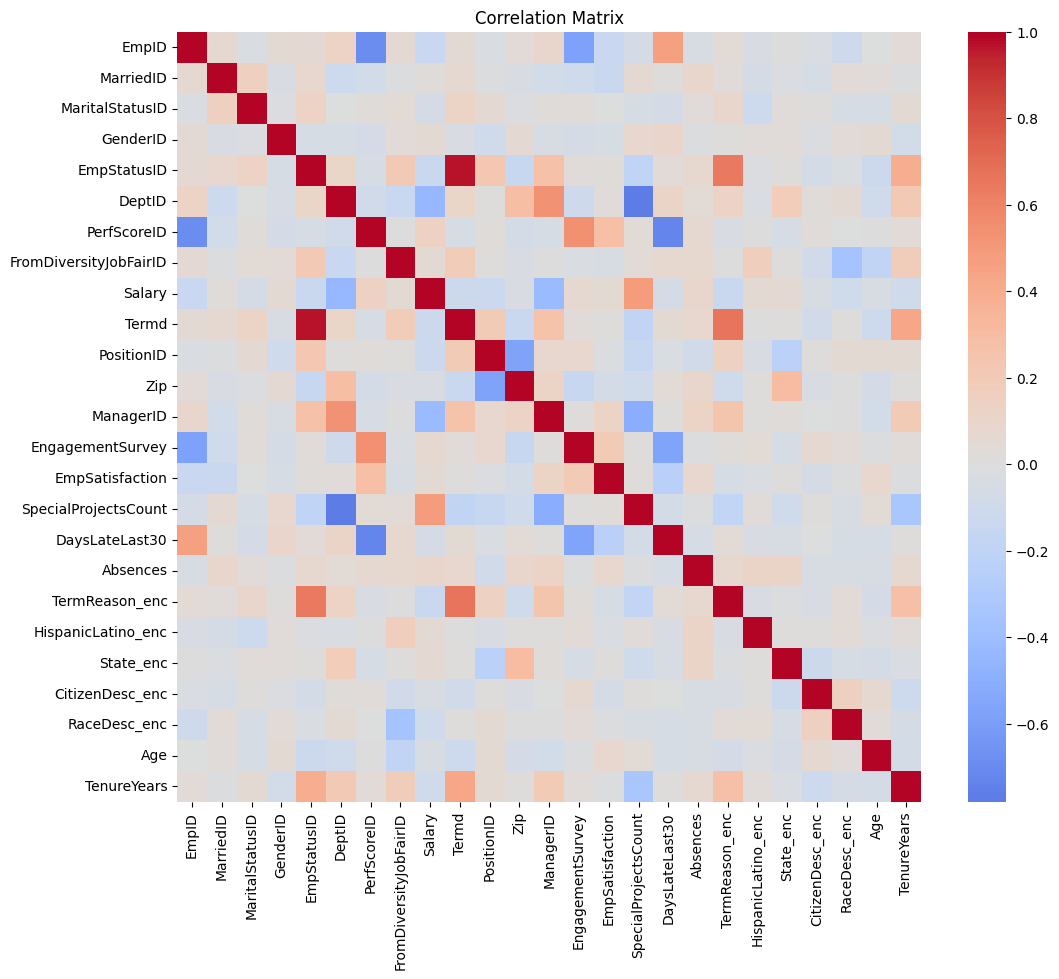

In [212]:
plt.figure(figsize=(12,10))

corr_matrix = df_filtered.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

### Correlation with Target (Exploration)

This correlation is computed on the full dataset for exploratory purposes only.

For the final interpretation of turnover drivers, we will use a cleaned version (`corr_target_clean`)
that excludes leakage-prone, identifier and sensitive variables.

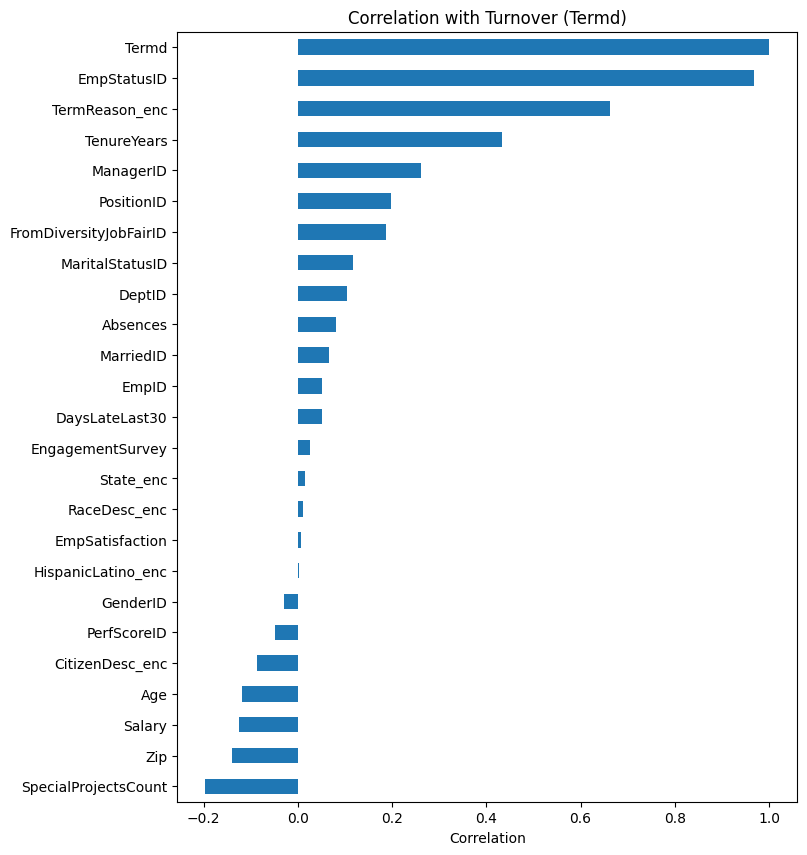

In [213]:
corr_target = df_filtered.corr(numeric_only=True)["Termd"].sort_values(ascending=False)

plt.figure(figsize=(8,10))
corr_target.sort_values().plot(kind="barh")
plt.title("Correlation with Turnover (Termd)")
plt.xlabel("Correlation")
plt.show()

### Analysis Dataset

At this stage, we work with two versions of the dataset:

- `df_filtered`: contains all remaining employees after filtering.  
  It is used for data understanding and visualization.

- `df_analysis`: a cleaned version of the dataset, where we remove variables that could introduce:
  - data leakage (e.g. TermReason)
  - identifiers (e.g. IDs)
  - sensitive attributes (e.g. ethnicity)

All correlation-based analysis and feature selection are performed using `df_analysis`.

This ensures that the identified turnover drivers are reliable and interpretable.

In [214]:
# removing the features that are useless and can cause data leakage
df_analysis = df_filtered.drop(columns=[
    "EmpStatusID",
    "TermReason_enc",
    #"ManagerID",
    #"PositionID",
    #"DeptID",
    #"Zip"
])

# clean correlation 
corr_target_clean = df_analysis.corr(numeric_only=True)["Termd"].sort_values(ascending=False)

print(corr_target_clean)

Termd                     1.000000
TenureYears               0.432878
ManagerID                 0.261093
PositionID                0.198464
FromDiversityJobFairID    0.187932
MaritalStatusID           0.118139
DeptID                    0.103470
Absences                  0.080404
MarriedID                 0.065167
EmpID                     0.051809
DaysLateLast30            0.051310
EngagementSurvey          0.026901
State_enc                 0.014920
RaceDesc_enc              0.010464
EmpSatisfaction           0.006630
HispanicLatino_enc        0.001946
GenderID                 -0.030019
PerfScoreID              -0.048282
CitizenDesc_enc          -0.087345
Age                      -0.117612
Salary                   -0.125330
Zip                      -0.138834
SpecialProjectsCount     -0.196115
Name: Termd, dtype: float64


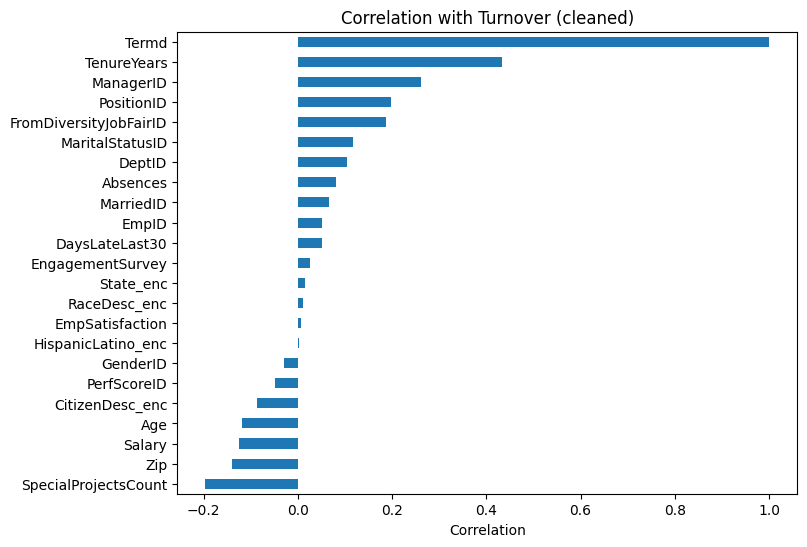

In [215]:
plt.figure(figsize=(8,6))

corr_target_clean.sort_values().plot(kind="barh")

plt.title("Correlation with Turnover (cleaned)")
plt.xlabel("Correlation")

plt.show()

In [216]:
# Select the most relevant turnover factors from the cleaned analysis

important_features_clean = corr_target_clean.drop(labels=["Termd"], errors="ignore")
important_features_clean = important_features_clean[abs(important_features_clean) > 0.1]

print("Most important features based on the cleaned correlation threshold:")
print(important_features_clean.sort_values(ascending=False))

Most important features based on the cleaned correlation threshold:
TenureYears               0.432878
ManagerID                 0.261093
PositionID                0.198464
FromDiversityJobFairID    0.187932
MaritalStatusID           0.118139
DeptID                    0.103470
Age                      -0.117612
Salary                   -0.125330
Zip                      -0.138834
SpecialProjectsCount     -0.196115
Name: Termd, dtype: float64


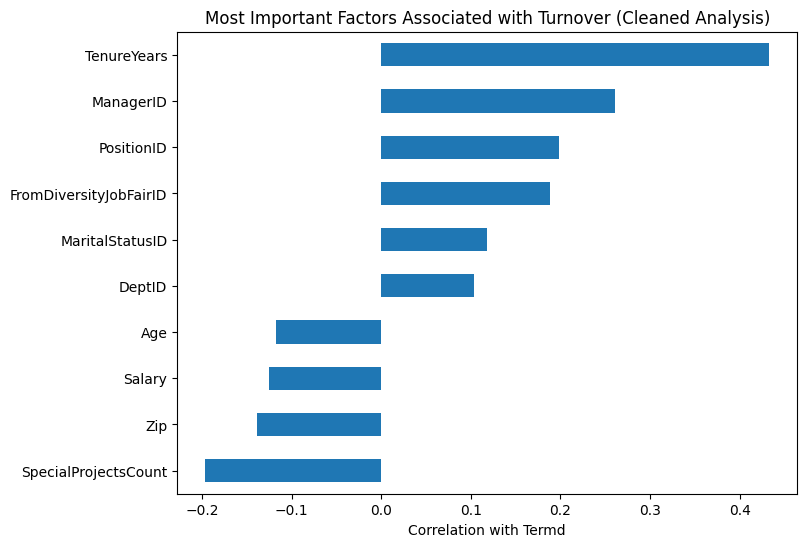

In [217]:
# Visualization of the cleaned important features

plt.figure(figsize=(8,6))
important_features_clean.sort_values().plot(kind="barh")

plt.title("Most Important Factors Associated with Turnover (Cleaned Analysis)")
plt.xlabel("Correlation with Termd")

plt.show()

# Predictive model

At this stage, we train a classification model to estimate the probability that an employee will leave the company.

In [218]:
# Prepare data for modeling

# Keep employee information for later display in the top 5
employee_info = df_filtered.loc[:, ["EmpID"]].copy()

# Keep only numerical columns for the model
df_model = df_analysis.select_dtypes(include=["number"]).copy()

# Remove columns that should not be used as predictive features
X = df_model.drop(columns=["Termd", "TermReason_enc"], errors="ignore")
y = df_model["Termd"].copy()

# Align employee information with the model dataset
employee_info = employee_info.loc[X.index].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used for modeling:")
print(X.columns.tolist())

X.head()

X shape: (293, 22)
y shape: (293,)

Features used for modeling:
['EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'PositionID', 'Zip', 'ManagerID', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'HispanicLatino_enc', 'State_enc', 'CitizenDesc_enc', 'RaceDesc_enc', 'Age', 'TenureYears']


,EmpID,MarriedID,MaritalStatusID,GenderID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,PositionID,Zip,...,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,HispanicLatino_enc,State_enc,CitizenDesc_enc,RaceDesc_enc,Age,TenureYears
0,10026,0,0,1,5,4,0,62506,19,1960,...,5,0,0,1,0,10,2,5,43,15
1,10084,1,1,1,3,3,0,104437,27,2148,...,3,6,0,17,0,10,2,5,0,11
2,10196,1,1,0,5,3,0,64955,20,1810,...,3,0,0,3,0,10,2,5,38,15
3,10088,1,1,0,5,3,0,64991,19,1886,...,5,0,0,15,0,10,2,5,38,19
4,10069,0,2,0,5,3,0,50825,19,2169,...,4,0,0,2,0,10,2,5,37,15


In [219]:
# Check missing values in modeling data

missing_counts = X.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_counts)

Columns with missing values:
ManagerID    8
dtype: int64


### Model Choice

We start with Logistic Regression because it is simple, interpretable and well suited to an explainable AI approach.

This model allows us to estimate a turnover probability for each employee.

In [220]:
# Train / Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (234, 22) (234,)
Test set: (59, 22) (59,)


In [221]:
# ===============================
# Train Logistic Regression with imputation
# ===============================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


/home/ovia/Hackathon_AI_explainability-/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Evaluation

We evaluate the model on the test set using standard classification metrics.
The goal is not only performance, but also interpretability and practical usefulness for HR decision support.

In [222]:
# Evaluate the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7457627118644068
ROC-AUC: 0.7549019607843137

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.86      0.83        42
           1       0.57      0.47      0.52        17

    accuracy                           0.75        59
   macro avg       0.69      0.66      0.67        59
weighted avg       0.73      0.75      0.74        59

Confusion Matrix:
[[36  6]
 [ 9  8]]


In [223]:
# Build Top 5 at-risk employees from the test set

results_test = employee_info.loc[X_test.index].copy()
results_test["actual_turnover"] = y_test
results_test["predicted_turnover"] = y_pred
results_test["risk_score"] = y_proba

top_5_test = results_test.sort_values(by="risk_score", ascending=False).head(5)

top_5_test

,EmpID,actual_turnover,predicted_turnover,risk_score
280,10268,1,1,0.998227
3,10088,0,1,0.956159
89,10189,1,1,0.913316
256,10095,1,1,0.837168
54,10282,0,1,0.705285


### HR-Oriented Top 5 Risk Ranking

The following table shows the employees with the highest predicted turnover probability in the test set.
This ranking can support HR prioritization and retention actions.

In [224]:
# Build Top 5 at-risk employees on the full dataset

full_proba = model.predict_proba(X)[:, 1]

results_full = employee_info.copy()
results_full["actual_turnover"] = y
results_full["risk_score"] = full_proba

top_5_full = results_full.sort_values(by="risk_score", ascending=False).head(5)

top_5_full

,EmpID,actual_turnover,risk_score
280,10268,1,0.998227
276,10221,1,0.977710
3,10088,0,0.956159
97,10080,0,0.949251
214,10286,1,0.939802


### Explainability with SHAP

To make the model understandable for HR, we use SHAP values to explain why an employee is considered at risk.

This helps identify the main factors driving each individual prediction.

In [225]:
# Prepare imputed data for SHAP

imputer = model.named_steps["imputer"]
classifier = model.named_steps["classifier"]

X_train_imputed = pd.DataFrame(
    imputer.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Imputed train shape:", X_train_imputed.shape)
print("Imputed test shape:", X_test_imputed.shape)

Imputed train shape: (234, 22)
Imputed test shape: (59, 22)


In [226]:
# SHAP explainability

import shap

explainer = shap.LinearExplainer(classifier, X_train_imputed)
shap_values = explainer(X_test_imputed)

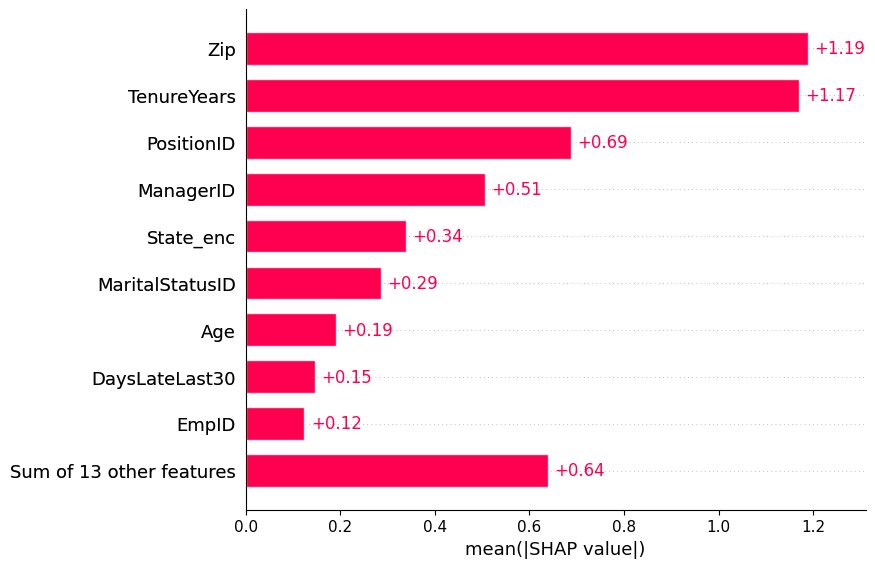

In [227]:
# Global feature importance

shap.plots.bar(shap_values)

Employee ID: 10268
Risk score: 0.9982267950252592


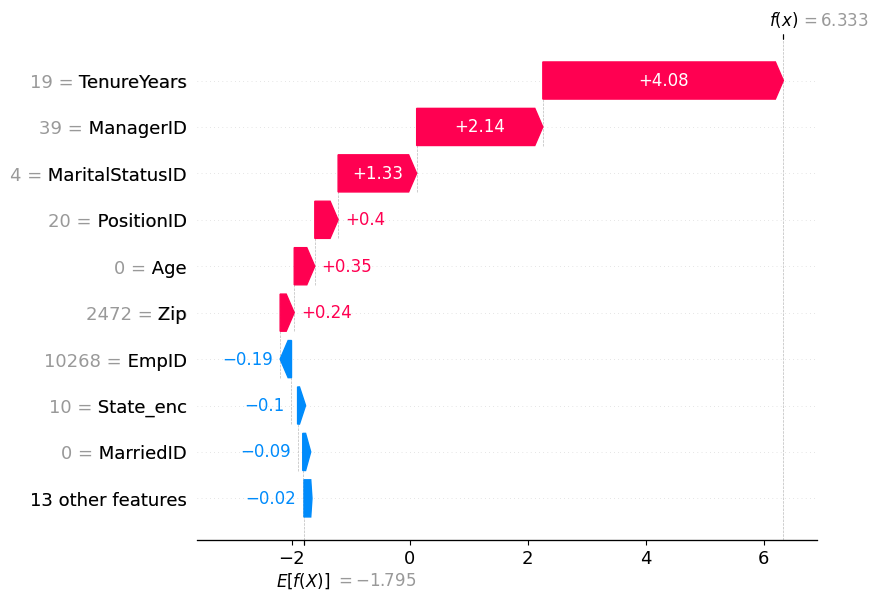

In [228]:
# Explain the highest-risk employee in the test set

top_employee_index = top_5_test.index[0]
row_position = list(X_test_imputed.index).index(top_employee_index)

print("Employee ID:", results_test.loc[top_employee_index, "EmpID"])
if "Employee_Name" in results_test.columns:
    print("Employee Name:", results_test.loc[top_employee_index, "Employee_Name"])
print("Risk score:", results_test.loc[top_employee_index, "risk_score"])

shap.plots.waterfall(shap_values[row_position])

### Ethical Considerations

This model is intended as a decision-support tool not as an automated decision-maker.

Predictions must be interpreted carefully and combined with human judgment.
Sensitive attributes should not be used as direct grounds for HR action.

### Predicting Risk for Active Employees

The model is trained on both active and former employees in order to learn the difference between staying and leaving.

However, for business use, predictions are only applied to employees who are still active (Termd = 0).

This allows us to identify employees currently at risk of leaving and support HR decision-making.

In [229]:
# Filter active employees only

active_employees = df_filtered[df_filtered["Termd"] == 0]

print("Number of active employees:", active_employees.shape[0])

Number of active employees: 207


In [230]:
# Get features for active employees

X_active = X.loc[active_employees.index]

print("X_active shape:", X_active.shape)

X_active shape: (207, 22)


In [231]:
# Predict risk for active employees

proba_active = model.predict_proba(X_active)[:, 1]

In [232]:
# Build Top 5 at-risk active employees

results_active = employee_info.loc[X_active.index].copy()
results_active["risk_score"] = proba_active

top_5_active = results_active.sort_values(by="risk_score", ascending=False).head(5)

top_5_active

,EmpID,risk_score
3,10088,0.956159
97,10080,0.949251
222,10164,0.890501
263,10302,0.877936
79,10211,0.808050


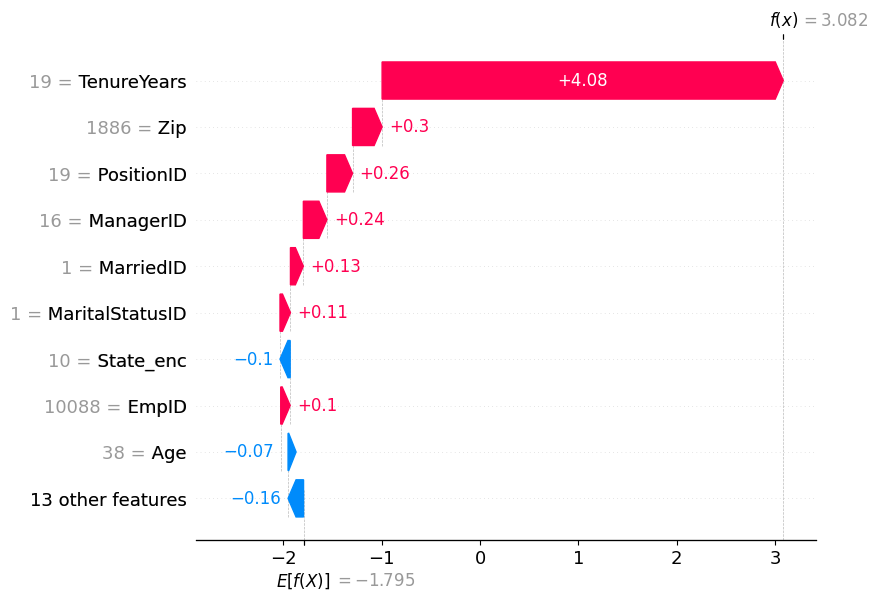

In [233]:
# Explain one active employee from Top 5

top_employee_index = top_5_active.index[0]

if top_employee_index in X_test_imputed.index:
    row_position = list(X_test_imputed.index).index(top_employee_index)
    shap.plots.waterfall(shap_values[row_position])
else:
    print("This employee is not in the test set, SHAP explanation not available here.")